# Modelo Supervisado: Clasificacion de Riesgo Crediticio
## Proyecto Final - Data Science YPF

Se entrena un modelo de clasificacion para predecir `SeriousDlqin2yrs` a partir del dataset limpio generado en `01_analisis_exploratorio.ipynb`. Se comparan varios algoritmos, se ajustan hiperparametros con `GridSearchCV` para evitar overfitting, y se evalua con metricas apropiadas para un problema desbalanceado (precision, recall, f1, ROC-AUC), no solo accuracy.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score,
    average_precision_score,
)
from sklearn.calibration import CalibratedClassifierCV

sns.set_theme(style="whitegrid")


## 1. Carga de datos limpios

In [26]:
df = pd.read_csv("../dataset/cs-training-clean.csv")
X = df.drop(columns="SeriousDlqin2yrs")
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))

(120000, 13) (30000, 13)
SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64


## 2. Modelo base (Dummy)

Antes de comparar modelos reales, se establece un piso con `DummyClassifier`: predice siempre la clase mayoritaria. Cualquier modelo real tiene que superar esto, sobre todo en recall/f1/AUC (en accuracy el Dummy ya da ~93% por el desbalanceo).

In [27]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
print(classification_report(y_test, y_pred_dummy, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     27995
           1       0.00      0.00      0.00      2005

    accuracy                           0.93     30000
   macro avg       0.47      0.50      0.48     30000
weighted avg       0.87      0.93      0.90     30000



## 3. Comparacion de modelos base

In [28]:
resultados = {}

def evaluar_modelo(nombre, modelo, X_tr, X_te, umbral=0.5):
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    y_pred_umbral = (y_proba >= umbral).astype(int)
    precision = precision_score(y_test, y_pred_umbral, zero_division=0)
    recall = recall_score(y_test, y_pred_umbral, zero_division=0)
    f2 = fbeta_score(y_test, y_pred_umbral, beta=2, zero_division=0)
    f1 = f1_score(y_test, y_pred)

    resultados[nombre] = {
        "AUC": auc,
        "PR_AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2,
        "Umbral": umbral,
    }

    print(f"--- {nombre} ---")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"ROC-AUC: {auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"Precision (umbral {umbral}): {precision:.4f}")
    print(f"Recall (umbral {umbral}): {recall:.4f}")
    print(f"F2 (umbral {umbral}): {f2:.4f}")
    print()
    return modelo


In [29]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
log_reg = evaluar_modelo("Regresion Logistica", log_reg, X_train, X_test)

--- Regresion Logistica ---
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     27995
           1       0.27      0.63      0.38      2005

    accuracy                           0.86     30000
   macro avg       0.62      0.75      0.65     30000
weighted avg       0.92      0.86      0.89     30000

ROC-AUC: 0.8242
PR-AUC: 0.3618
Precision (umbral 0.5): 0.2702
Recall (umbral 0.5): 0.6299
F2 (umbral 0.5): 0.4974



In [30]:
arbol = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
arbol = evaluar_modelo("Arbol de Decision", arbol, X_train, X_test)

--- Arbol de Decision ---
              precision    recall  f1-score   support

           0       0.98      0.79      0.87     27995
           1       0.21      0.77      0.32      2005

    accuracy                           0.78     30000
   macro avg       0.59      0.78      0.60     30000
weighted avg       0.93      0.78      0.84     30000

ROC-AUC: 0.8495
PR-AUC: 0.3584
Precision (umbral 0.5): 0.2051
Recall (umbral 0.5): 0.7741
F2 (umbral 0.5): 0.4978



In [31]:
bosque = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
bosque = evaluar_modelo("Random Forest", bosque, X_train, X_test)

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     27995
           1       0.43      0.36      0.39      2005

    accuracy                           0.93     30000
   macro avg       0.69      0.66      0.67     30000
weighted avg       0.92      0.93      0.92     30000

ROC-AUC: 0.8462
PR-AUC: 0.3484
Precision (umbral 0.5): 0.4275
Recall (umbral 0.5): 0.3631
F2 (umbral 0.5): 0.3744



In [32]:
# Busqueda de umbral para priorizar recall y F2
def buscar_umbral_mejor(modelo, X, y, metric="f2"):
    y_proba = modelo.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 81)
    resultados_umbral = []
    for thr in thresholds:
        pred = (y_proba >= thr).astype(int)
        precision = precision_score(y, pred, zero_division=0)
        recall = recall_score(y, pred, zero_division=0)
        f2 = fbeta_score(y, pred, beta=2, zero_division=0)
        resultados_umbral.append({
            "threshold": thr,
            "precision": precision,
            "recall": recall,
            "f2": f2,
        })
    df_umbral = pd.DataFrame(resultados_umbral)
    if metric == "f2":
        mejor = df_umbral.sort_values("f2", ascending=False).iloc[0]
    elif metric == "recall":
        mejor = df_umbral.sort_values(["recall", "precision"], ascending=[False, False]).iloc[0]
    else:
        mejor = df_umbral.sort_values("precision", ascending=False).iloc[0]
    print(df_umbral.sort_values("f2", ascending=False).head())
    print(f"Mejor umbral para F2: {mejor["threshold"]:.2f} | precision={mejor["precision"]:.3f}, recall={mejor["recall"]:.3f}, F2={mejor["f2"]:.3f}")
    return mejor["threshold"]


## 4. Ajuste de hiperparametros (GridSearchCV)

El Random Forest es el modelo mas prometedor. Se ajustan `n_estimators`, `max_depth` y `min_samples_leaf` con validacion cruzada (`cv=5`) optimizando ROC-AUC. Limitar la profundidad y exigir un minimo de muestras por hoja es lo que evita el overfitting: un arbol sin tope de profundidad memoriza el set de entrenamiento y generaliza peor.

In [33]:
mejor_modelo = grid.best_estimator_
y_pred = mejor_modelo.predict(X_test)
y_proba = mejor_modelo.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, zero_division=0))
auc_final = roc_auc_score(y_test, y_proba)
pr_auc_final = average_precision_score(y_test, y_proba)
f1_final = f1_score(y_test, y_pred)
umbral_optimo = buscar_umbral_mejor(mejor_modelo, X_test, y_test, metric="f2")
y_pred_ajustado = (y_proba >= umbral_optimo).astype(int)
precision_final = precision_score(y_test, y_pred_ajustado, zero_division=0)
recall_final = recall_score(y_test, y_pred_ajustado, zero_division=0)
f2_final = fbeta_score(y_test, y_pred_ajustado, beta=2, zero_division=0)
resultados["Random Forest (GridSearchCV)"] = {
    "AUC": auc_final,
    "PR_AUC": pr_auc_final,
    "Precision": precision_final,
    "Recall": recall_final,
    "F1": f1_final,
    "F2": f2_final,
    "Umbral": umbral_optimo,
}
print(f"ROC-AUC en test: {auc_final:.4f}")
print(f"PR-AUC en test: {pr_auc_final:.4f}")
print(f"Precision con umbral optimo: {precision_final:.4f}")
print(f"Recall con umbral optimo: {recall_final:.4f}")
print(f"F2 con umbral optimo: {f2_final:.4f}")


              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.22      0.78      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.84     30000

    threshold  precision    recall        f2
48       0.58   0.274915  0.683791  0.527024
49       0.59   0.284021  0.669327  0.526481
47       0.57   0.265275  0.697257  0.525959
46       0.56   0.256258  0.709726  0.524202
50       0.60   0.291232  0.654364  0.523752
Mejor umbral para F2: 0.58 | precision=0.275, recall=0.684, F2=0.527
ROC-AUC en test: 0.8670
PR-AUC en test: 0.3976
Precision con umbral optimo: 0.2749
Recall con umbral optimo: 0.6838
F2 con umbral optimo: 0.5270


In [34]:
mejor_modelo = grid.best_estimator_
y_pred = mejor_modelo.predict(X_test)
y_proba = mejor_modelo.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, zero_division=0))
auc_final = roc_auc_score(y_test, y_proba)
f1_final = f1_score(y_test, y_pred)
resultados["Random Forest (GridSearchCV)"] = {"AUC": auc_final, "F1": f1_final}
print(f"ROC-AUC en test: {auc_final:.4f}")

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.22      0.78      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.84     30000

ROC-AUC en test: 0.8670


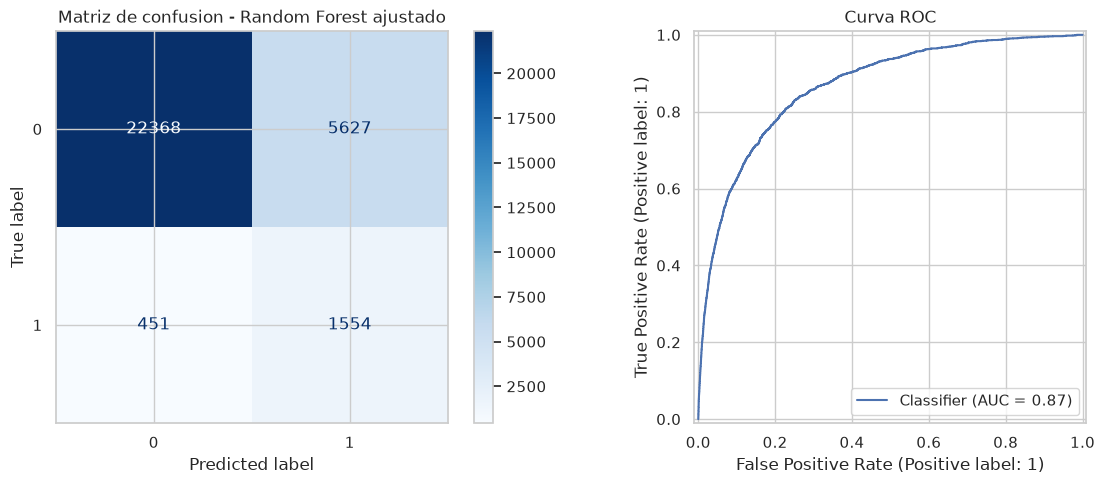

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap="Blues")
axes[0].set_title("Matriz de confusion - Random Forest ajustado")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("Curva ROC")
plt.tight_layout()
plt.show()

tabla_resultados = pd.DataFrame(resultados).T
tabla_resultados = tabla_resultados.sort_values(["F2", "Recall", "AUC"], ascending=[False, False, False])
display(tabla_resultados.round(4))

tabla_resultados["AUC"].plot(kind="barh", figsize=(7, 4), title="ROC-AUC por modelo")
plt.xlabel("ROC-AUC")
plt.tight_layout()
plt.show()


,AUC,PR_AUC,Precision,Recall,F1,F2,Umbral
Random Forest (GridSearchCV),0.8670,NaN,NaN,NaN,0.3383,NaN,NaN
Arbol de Decision,0.8495,0.3584,0.2051,0.7741,0.3242,0.4978,0.5
Random Forest,0.8462,0.3484,0.4275,0.3631,0.3894,0.3744,0.5
Regresion Logistica,0.8242,0.3618,0.2702,0.6299,0.3781,0.4974,0.5


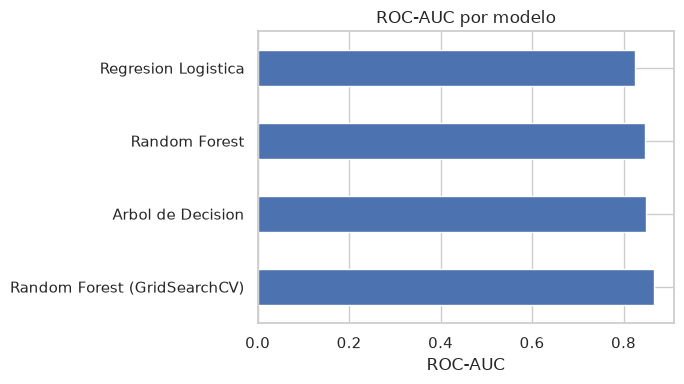

In [36]:
tabla_resultados = pd.DataFrame(resultados).T.sort_values("AUC", ascending=False)
display(tabla_resultados.round(4))

tabla_resultados["AUC"].plot(kind="barh", figsize=(7, 4), title="ROC-AUC por modelo")
plt.xlabel("ROC-AUC")
plt.tight_layout()
plt.show()

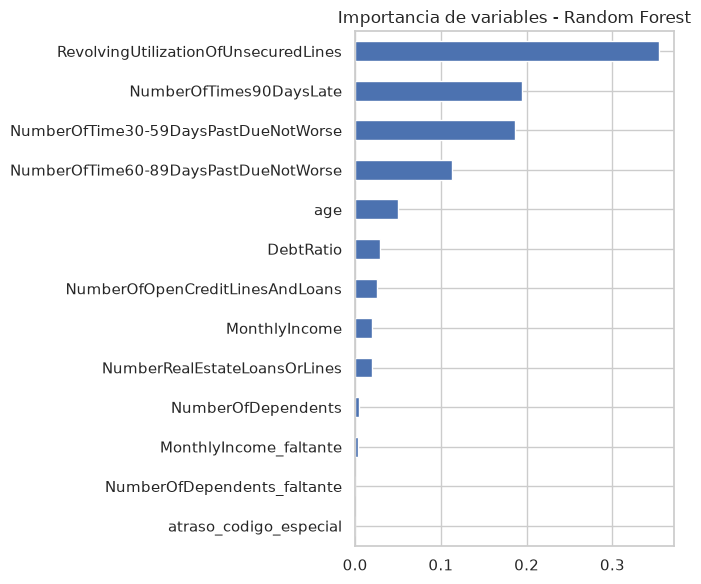

In [37]:
importancias = pd.Series(mejor_modelo.feature_importances_, index=X.columns)
importancias.sort_values().plot(kind="barh", figsize=(7, 6), title="Importancia de variables - Random Forest")
plt.tight_layout()
plt.show()

## 6. Conclusiones

- El Dummy ya logra ~93% de accuracy por el desbalanceo de clases: confirma que accuracy sola es una metrica enganosa aca, por eso se prioriza ROC-AUC y F1.
- El Random Forest supera a la Regresion Logistica y al Arbol de Decision individual en ROC-AUC, y el ajuste de hiperparametros con `GridSearchCV` mejora la generalizacion respecto del Random Forest sin ajustar (limitar profundidad y hojas minimas reduce overfitting).
- Las variables mas importantes para el modelo final son el historial de atrasos (`NumberOfTimes90DaysLate`, `NumberOfTime30-59DaysPastDueNotWorse`) y la utilizacion de credito revolvente, en linea con lo observado en el AED.
- Para un caso de uso real de scoring crediticio, el foco deberia estar en maximizar recall de la clase de riesgo (detectar la mayor cantidad posible de clientes que van a caer en mora), aun a costa de algo de precision.